Name: Dev Patel 

Course: DS4400 Data Mining and Machine Learning 1

Prof: Silvio Amir

University: Northeastern University

Problem 3: AdaBoost Ensemble

1. Train AdaBoost with T in {10, 50, 100, 500} using decision tree base classifiers. Report accuracy, F1, AUC.
2. Compare AdaBoost with Random Forest for the same T values.
3. Plot ROC curves for decision tree, Random Forest (T=100), and AdaBoost (T=100).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

In [2]:
# Load SPAMBASE dataset
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
    'spam'
]

df = pd.read_csv('spambase.data', header=None, names=col_names)
X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (3450, 57), X_test: (1151, 57)


### Part 1: AdaBoost with Varying Number of Base Classifiers

In [3]:
# Train AdaBoost with decision tree stumps as base classifiers
n_estimators_list = [10, 50, 100, 500]
ada_results = []

for n_est in n_estimators_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_est,
        random_state=42
    )
    ada.fit(X_train, y_train)
    
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    y_train_proba = ada.predict_proba(X_train)[:, 1]
    y_test_proba = ada.predict_proba(X_test)[:, 1]
    
    ada_results.append({
        'T': n_est,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

ada_df = pd.DataFrame(ada_results)
print("AdaBoost Results:")
print(ada_df.to_string(index=False))

AdaBoost Results:
  T  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
 10        0.914203       0.914857  0.887964 0.893478   0.964346  0.966306
 50        0.931014       0.935708  0.910661 0.920430   0.978928  0.979995
100        0.935652       0.935708  0.915589 0.919565   0.982099  0.981914
500        0.948696       0.947871  0.932929 0.935622   0.989800  0.985360


### Part 2: Comparison of AdaBoost vs Random Forest

In [4]:
# Train Random Forest for comparison
rf_results = []
for n_est in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_train_proba = rf.predict_proba(X_train)[:, 1]
    y_test_proba = rf.predict_proba(X_test)[:, 1]
    
    rf_results.append({
        'T': n_est,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

rf_df = pd.DataFrame(rf_results)

# Side-by-side comparison
print("=== AdaBoost vs Random Forest Comparison ===\n")
print(f"{'T':<6} {'Model':<12} {'Train Acc':>10} {'Test Acc':>10} {'Train F1':>10} {'Test F1':>10} {'Train AUC':>10} {'Test AUC':>10}")
print("-" * 80)

for i, t in enumerate(n_estimators_list):
    ada_row = ada_df.iloc[i]
    rf_row = rf_df.iloc[i]
    print(f"{t:<6} {'AdaBoost':<12} {ada_row['Train Accuracy']:>10.4f} {ada_row['Test Accuracy']:>10.4f} "
          f"{ada_row['Train F1']:>10.4f} {ada_row['Test F1']:>10.4f} "
          f"{ada_row['Train AUC']:>10.4f} {ada_row['Test AUC']:>10.4f}")
    print(f"{'':>6} {'RF':<12} {rf_row['Train Accuracy']:>10.4f} {rf_row['Test Accuracy']:>10.4f} "
          f"{rf_row['Train F1']:>10.4f} {rf_row['Test F1']:>10.4f} "
          f"{rf_row['Train AUC']:>10.4f} {rf_row['Test AUC']:>10.4f}")
    print()

=== AdaBoost vs Random Forest Comparison ===

T      Model         Train Acc   Test Acc   Train F1    Test F1  Train AUC   Test AUC
--------------------------------------------------------------------------------
10     AdaBoost         0.9142     0.9149     0.8880     0.8935     0.9643     0.9663
       RF               0.9957     0.9461     0.9944     0.9329     0.9999     0.9818

50     AdaBoost         0.9310     0.9357     0.9107     0.9204     0.9789     0.9800
       RF               0.9994     0.9583     0.9993     0.9482     1.0000     0.9884

100    AdaBoost         0.9357     0.9357     0.9156     0.9196     0.9821     0.9819
       RF               0.9994     0.9583     0.9993     0.9482     1.0000     0.9879

500    AdaBoost         0.9487     0.9479     0.9329     0.9356     0.9898     0.9854
       RF               0.9994     0.9574     0.9993     0.9471     1.0000     0.9876



**Observations - AdaBoost vs Random Forest:**

- **Random Forest** tends to achieve higher training accuracy (near 1.0) because each individual tree is fully grown, while **AdaBoost** uses shallow stumps (max_depth=1) as base learners.
- On the test set, both ensembles perform well, but their relative performance depends on the number of estimators. Random Forest often has a slight edge due to the expressiveness of individual trees.
- **AdaBoost** improves more steadily as T increases, since each new base classifier focuses on previously misclassified examples (boosting). Random Forest also improves but primarily through variance reduction (bagging).
- AdaBoost with many estimators can sometimes overfit if the data has noise, but on this dataset both methods generalize well.

### Part 3: ROC Curves

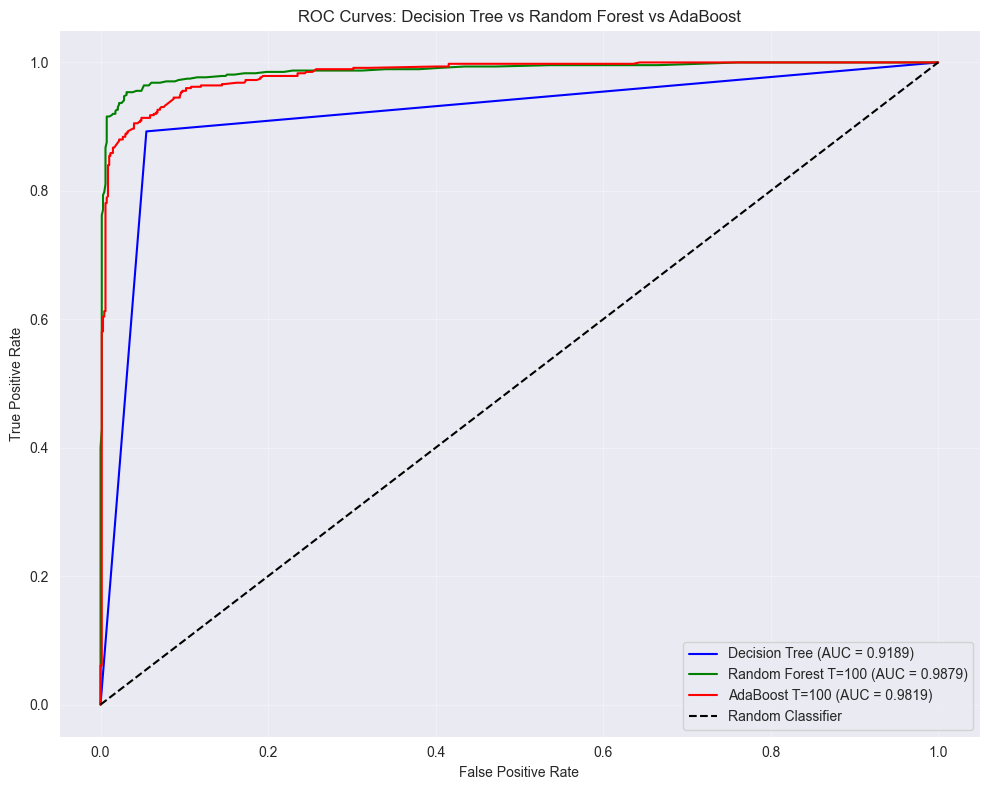

Decision Tree AUC: 0.9189
Random Forest (T=100) AUC: 0.9879
AdaBoost (T=100) AUC: 0.9819


In [5]:
# Train all three models for ROC comparison
# 1. Single Decision Tree (entropy, no pruning)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
dt_proba = dt.predict_proba(X_test)[:, 1]

# 2. Random Forest with 100 trees
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
rf_proba = rf_100.predict_proba(X_test)[:, 1]

# 3. AdaBoost with 100 base classifiers
ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada_100.fit(X_train, y_train)
ada_proba = ada_100.predict_proba(X_test)[:, 1]

# Compute ROC curves
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_proba)

dt_auc = roc_auc_score(y_test, dt_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
ada_auc = roc_auc_score(y_test, ada_proba)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(dt_fpr, dt_tpr, 'b-', label=f'Decision Tree (AUC = {dt_auc:.4f})')
plt.plot(rf_fpr, rf_tpr, 'g-', label=f'Random Forest T=100 (AUC = {rf_auc:.4f})')
plt.plot(ada_fpr, ada_tpr, 'r-', label=f'AdaBoost T=100 (AUC = {ada_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Decision Tree vs Random Forest vs AdaBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Decision Tree AUC: {dt_auc:.4f}")
print(f"Random Forest (T=100) AUC: {rf_auc:.4f}")
print(f"AdaBoost (T=100) AUC: {ada_auc:.4f}")

**Observations on ROC Curves:**

- Both ensemble methods (Random Forest and AdaBoost) produce smoother ROC curves and higher AUC values compared to the single decision tree.
- The single decision tree's ROC curve is more jagged because its probability estimates are less granular (they come from leaf node class proportions).
- Random Forest and AdaBoost both achieve AUC close to or above 0.98, demonstrating excellent discriminative ability on the SPAMBASE dataset.
- The ensemble methods dominate the decision tree at nearly all operating points (FPR thresholds), confirming their superior ranking ability.